<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nelson/customer_segmentation_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

from yellowbrick.cluster import KElbowVisualizer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.graph_objs as go

from google.colab import files
import os
import shutil
import joblib

# **Data Loading**


In [2]:
# Mengambil data menggunakan API dari Kaggle
if not os.path.exists('kaggle.json'):
  files.upload()
  print("API Key Received")

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
file1 = 'Online Retail.csv'
file2 = 'online_retail_II.csv'

if not (os.path.exists(file1) and os.path.exists(file2)):
  !cp kaggle.json ~/.kaggle/
  !chmod 600 ~/.kaggle/kaggle.json
  !kaggle datasets download -d viridianachow/online-retail-uci-dataset
  !kaggle datasets download -d mashlyn/online-retail-ii-uci
  !unzip online-retail-uci-dataset.zip
  !unzip online-retail-ii-uci.zip

In [4]:
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [5]:
df_1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [6]:
df_2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
# Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [8]:
# Gabung menjadi 1 DataFrame
df = pd.concat([df_1, df_2])

df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## **Exploratory Data Analysis (EDA)**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [10]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,1609280,1609280,1603444,1.609280e+06,1609280,1.609280e+06,1.231193e+06,1609280
unique,53628,5305,5698,NaN,70895,NaN,NaN,43
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,2228,8142,8287,NaN,1350,NaN,NaN,1476808
mean,NaN,NaN,NaN,9.808698e+00,NaN,4.636499e+00,1.531243e+04,NaN
std,NaN,NaN,NaN,1.892047e+02,NaN,1.152285e+02,1.702901e+03,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,1.234600e+04,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,1.396900e+04,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,1.522000e+04,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.130000e+00,1.679500e+04,NaN


In [11]:
# Memperbaiki format data dan menerapkan LabelEncoder
df_fixed = df.copy()
df_fixed = df_fixed.drop(['Description'], axis=1)

df_fixed = df_fixed[~df_fixed['Invoice'].astype(str).str.startswith('C', na=False)]

numeric_cols = ['Invoice', 'StockCode', 'Quantity', 'Price', 'CustomerID']

for col in numeric_cols:
    df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')

df_fixed['InvoiceDate'] = pd.to_datetime(df_fixed['InvoiceDate'], format='mixed')

df_lencoder = df_fixed.copy()

le = LabelEncoder()
df_lencoder['Country'] = le.fit_transform(df_lencoder['Country'])

In [12]:
df_lencoder.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1580498 entries, 0 to 1067370
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1580489 non-null  float64       
 1   StockCode    1395300 non-null  float64       
 2   Quantity     1580498 non-null  int64         
 3   InvoiceDate  1580498 non-null  datetime64[ns]
 4   Price        1580498 non-null  float64       
 5   CustomerID   1203544 non-null  float64       
 6   Country      1580498 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 96.5 MB


In [13]:
df_lencoder.describe(include='all')

,Invoice,StockCode,Quantity,InvoiceDate,Price,CustomerID,Country
count,1.580489e+06,1.395300e+06,1.580498e+06,1580498,1.580498e+06,1.203544e+06,1.580498e+06
mean,5.451426e+05,2.790092e+04,1.047360e+01,2011-03-05 18:31:11.666703616,3.883084e+00,1.531944e+04,3.813457e+01
min,4.894340e+05,1.000200e+04,-9.600000e+03,2009-12-01 07:45:00,-5.359436e+04,1.234600e+04,0.000000e+00
25%,5.280570e+05,2.178700e+04,1.000000e+00,2010-10-20 11:58:00,1.250000e+00,1.397500e+04,4.000000e+01
50%,5.483730e+05,2.242300e+04,3.000000e+00,2011-03-30 16:34:00,2.100000e+00,1.523800e+04,4.000000e+01
75%,5.667350e+05,2.298700e+04,1.000000e+01,2011-09-14 14:19:00,4.130000e+00,1.680100e+04,4.000000e+01
max,5.815870e+05,9.020800e+04,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,1.828700e+04,4.200000e+01
std,2.537267e+04,1.730115e+04,1.439335e+02,NaN,8.056432e+01,1.702300e+03,6.831865e+00


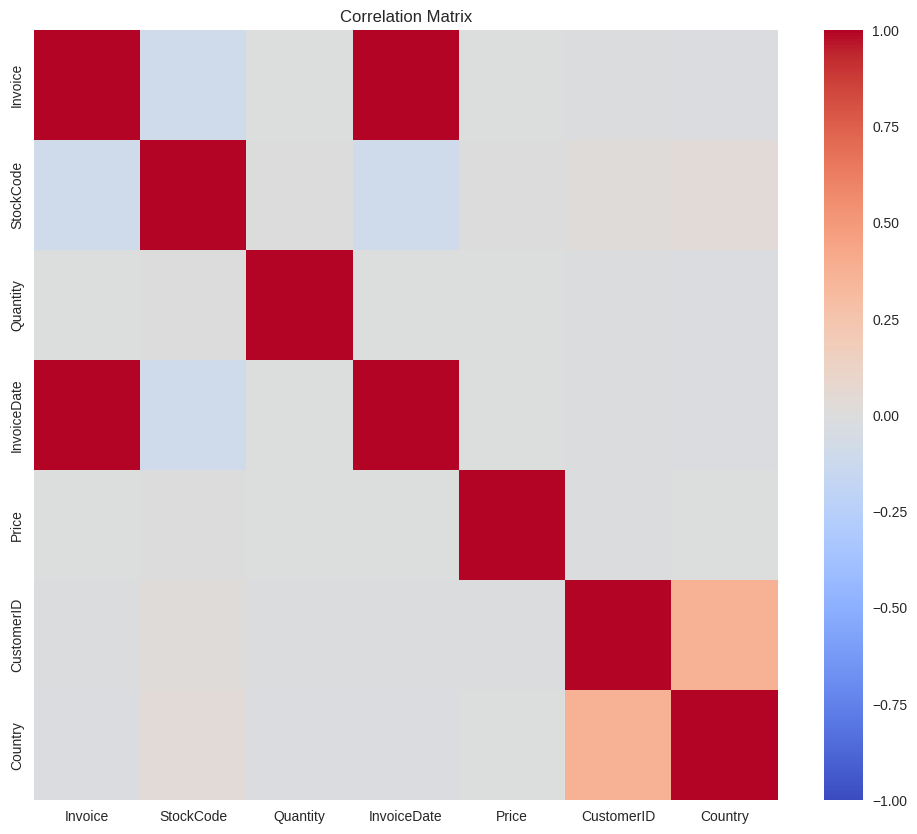

In [14]:
# Menampilkan Heatmap korelasi antar data
plt.figure(figsize=(12, 10))
correlation_matrix = df_lencoder.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

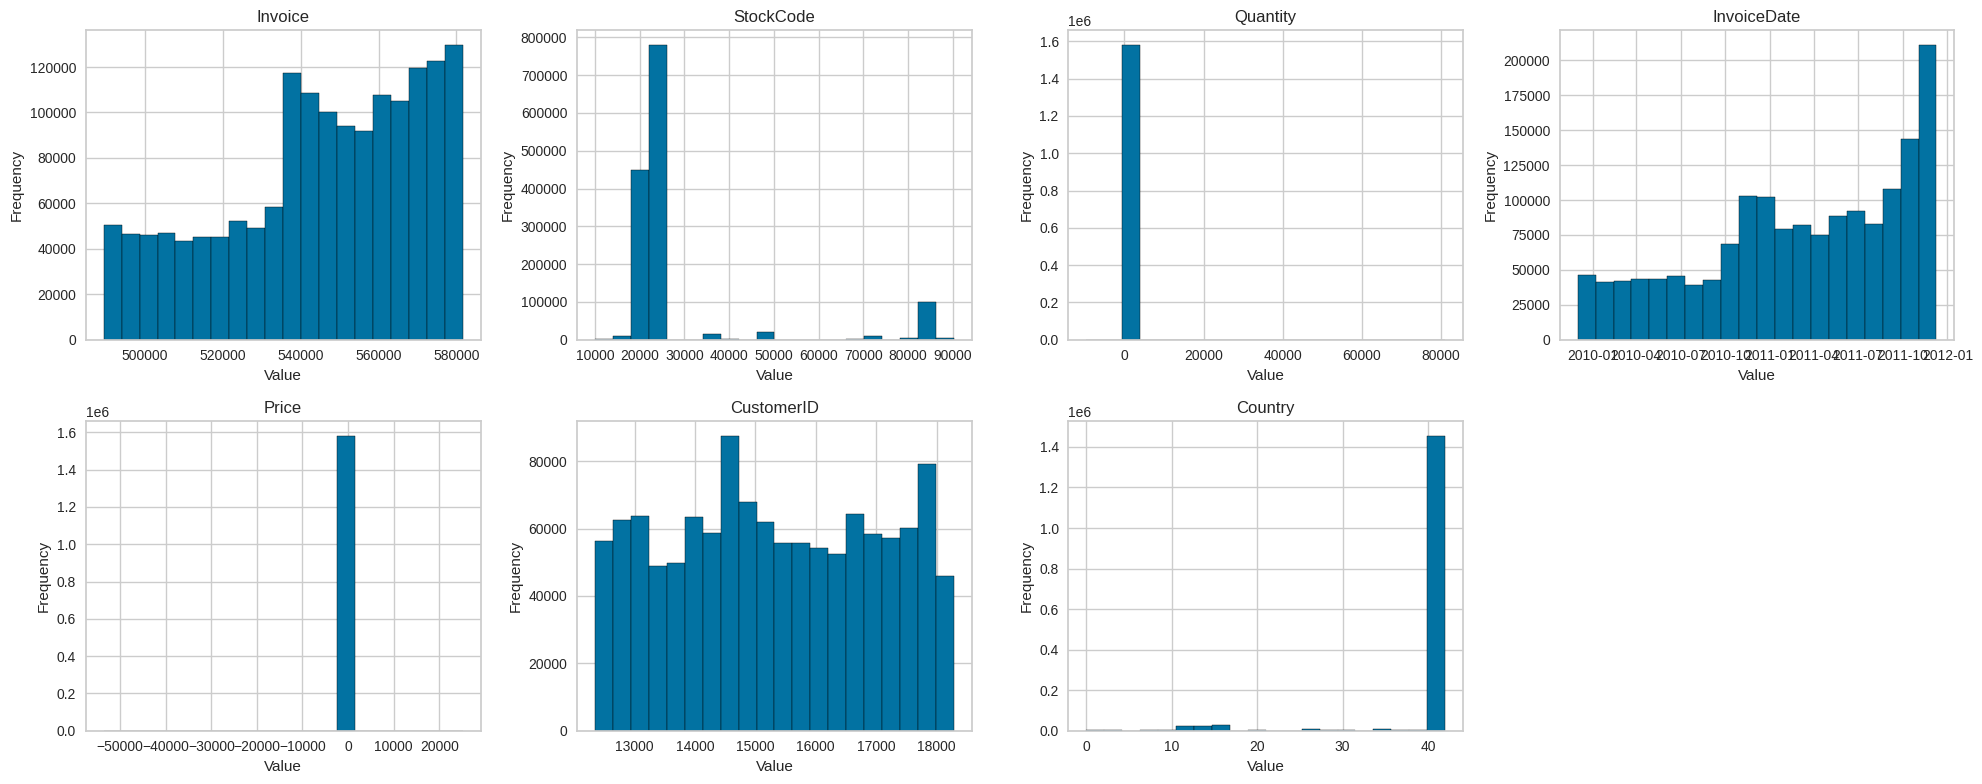

In [15]:
# Menampilkan Bar Chart untuk setiap kolom pada data
num_vars = df_lencoder.shape[1]

n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

for i, column in enumerate(df_lencoder.columns):
    df_lencoder[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Pre-processing**

## Raw Data

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1609280 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1609280 non-null  object 
 1   StockCode    1609280 non-null  object 
 2   Description  1603444 non-null  object 
 3   Quantity     1609280 non-null  int64  
 4   InvoiceDate  1609280 non-null  object 
 5   Price        1609280 non-null  float64
 6   CustomerID   1231193 non-null  float64
 7   Country      1609280 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 110.5+ MB


In [17]:
df.duplicated().sum()

np.int64(39603)

In [18]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,5729
Quantity,0
InvoiceDate,0
Price,0
CustomerID,370188
Country,0


In [20]:
df = df.dropna()

df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
CustomerID,0
Country,0


In [21]:
# Menghapus row Quantity dan Price yang memiliki nilai < 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [22]:
# Membuat kolom baru untuk perhitungan Monetary dan memperbaiki format InvoiceDate
df['TotalSales'] = df['Quantity'] * df['Price']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
tgl_pengambilan = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


## RFM

In [23]:
Recency = ('InvoiceDate', lambda x: (tgl_pengambilan - x.max()).days)
Frequency = ('Invoice', 'nunique')
Monetary = ('TotalSales', 'sum')

In [24]:
df_rfm = df.groupby('CustomerID').agg(
  Recency=Recency,
  Frequency=Frequency,
  Monetary=Monetary
).reset_index()

df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,154740.06
1,12347.0,2,8,9231.53
2,12348.0,75,5,3816.64
3,12349.0,19,4,6186.24
4,12350.0,310,1,668.80
...,...,...,...,...
5873,18283.0,4,22,4710.43
5874,18284.0,432,1,461.68
5875,18285.0,661,1,427.00
5876,18286.0,477,2,1296.43


In [25]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,4467.848445
std,1715.572666,209.338707,13.009406,21986.508987
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,468.485000
50%,15314.500000,96.000000,3.000000,1283.860000
75%,16797.750000,380.000000,7.000000,3419.705000
max,18287.000000,739.000000,398.000000,840644.340000


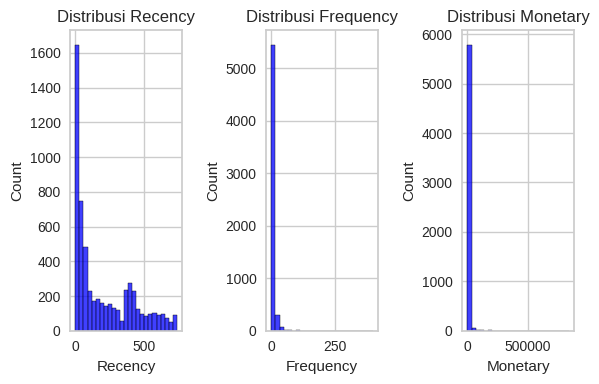

In [26]:
# Menampilkan distribusi RFM sebelum dilakukan preprocessing
columns = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(columns, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

In [27]:
# Menghapus Outlier pada RFM
df_rfm_clean = df_rfm.copy()

Q1 = df_rfm_clean[columns].quantile(0.25)
Q3 = df_rfm_clean[columns].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df_rfm_clean[columns] < (Q1 - 1.5 * IQR)) | (df_rfm_clean[columns] > (Q3 + 1.5 * IQR))).any(axis=1)

df_rfm_clean = df_rfm_clean[condition]

df_rfm.describe(include="all")

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,4467.848445
std,1715.572666,209.338707,13.009406,21986.508987
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,468.485000
50%,15314.500000,96.000000,3.000000,1283.860000
75%,16797.750000,380.000000,7.000000,3419.705000
max,18287.000000,739.000000,398.000000,840644.340000


In [28]:
# Melakukan transformai logaritmik pada RFM
df_rfm_log = df_rfm_clean.copy()
df_rfm_log = df_rfm_clean[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)

df_rfm_log.head()

,Recency,Frequency,Monetary
2,4.330733,1.791759,8.247388
3,2.995732,1.609438,8.730244
4,5.739793,0.693147,6.506979
5,5.929589,0.693147,5.710195
6,3.610918,2.397895,8.586137


In [29]:
# Melakukan Normalisasi pada RFM
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log)

df_rfm_scaled = pd.DataFrame(rfm_scaled, columns=df_rfm_log.columns, index=df_rfm_log.index)

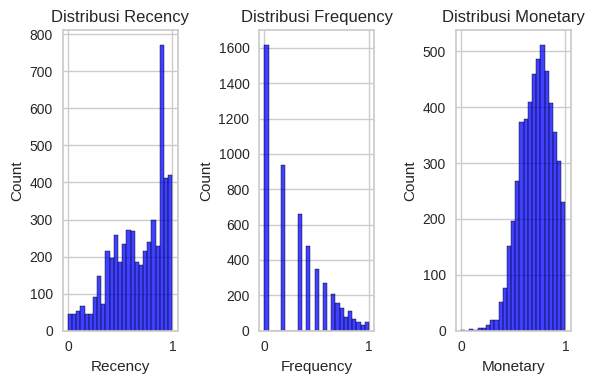

In [30]:
# Menampilkan distribusi RFM setelah Normalisasi
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm_scaled[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Clustering**

## KMeans

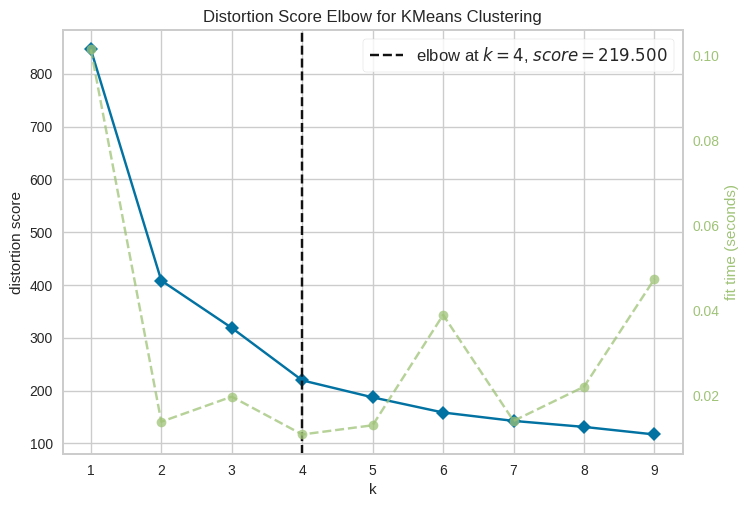

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
kmeans = KMeans()
Visualizer = KElbowVisualizer(kmeans, k=(1,10))
Visualizer.fit(df_rfm_scaled)
Visualizer.show()

In [32]:
X_model = df_rfm_scaled.values

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_model)
labels = kmeans.labels_

df_rfm_clean['Cluster'] = labels

def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]

        mean_recency = cluster_data[:, 0].mean()
        mean_frequency = cluster_data[:, 1].mean()
        mean_monetary = cluster_data[:, 2].mean()

        print(f"\nCluster {cluster_id + 1}:")
        print(f"Rata-rata (mean) Recency: {mean_recency}")
        print(f"Rata-rata (mean) Frequency: {mean_frequency}")
        print(f"Rata-rata (mean) Monetary: {mean_monetary}")

analyze_clusters(X_model, labels, k)

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata (mean) Recency: 0.39959242223624586
Rata-rata (mean) Frequency: 0.7046205576995265
Rata-rata (mean) Monetary: 0.8943642346547543

Cluster 2:
Rata-rata (mean) Recency: 0.8884930721381943
Rata-rata (mean) Frequency: 0.05859434364635738
Rata-rata (mean) Monetary: 0.5812697078778479

Cluster 3:
Rata-rata (mean) Recency: 0.7793639469863434
Rata-rata (mean) Frequency: 0.4616517874516885
Rata-rata (mean) Monetary: 0.7886391068130756

Cluster 4:
Rata-rata (mean) Recency: 0.4495913043975563
Rata-rata (mean) Frequency: 0.18804088500586824
Rata-rata (mean) Monetary: 0.7194460361551929


In [33]:
df_rfm_clean

,CustomerID,Recency,Frequency,Monetary,Cluster
2,12348.0,75,5,3816.64,2
3,12349.0,19,4,6186.24,0
4,12350.0,310,1,668.80,1
5,12351.0,375,1,300.93,1
6,12352.0,36,10,5355.88,0
...,...,...,...,...,...
5872,18282.0,8,2,356.10,3
5874,18284.0,432,1,461.68,1
5875,18285.0,661,1,427.00,1
5876,18286.0,477,2,1296.43,1


In [34]:
score = silhouette_score(df_rfm_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.39843769150208674


In [35]:
# Menampilkan visualisasi cluster dalam bentuk 3D
visual_3d = go.Scatter3d(
    x= df_rfm_clean['Recency'],
    y= df_rfm_clean['Frequency'],
    z= df_rfm_clean['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm_clean['Cluster'],
        size= 20,
        line=dict(
            color= df_rfm_clean['Cluster'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Clusters',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

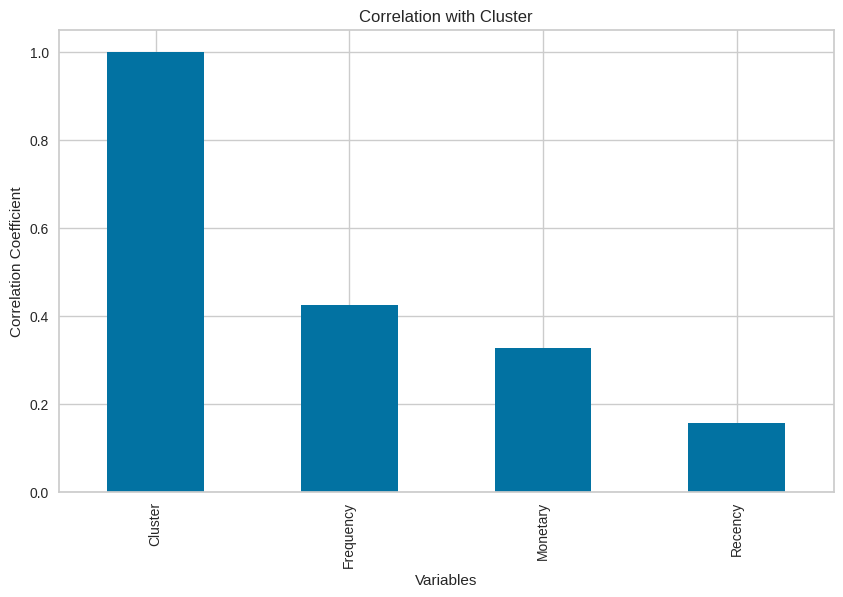

In [36]:
# Menghitung korelasi antara variabel target dan semua variabel lainnnya
numerical_cols = ['Recency', 'Frequency', 'Monetary', 'Cluster']

target_corr = df_rfm_clean[numerical_cols].corr()['Cluster']

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with Cluster')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

### PCA

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
df_PCA = pd.DataFrame(X_pca, columns=['PCA_1', 'PCA_2'])

kmeans_pca = KMeans(n_clusters=k, random_state=42)
kmeans_pca.fit(df_PCA)

c_labels = kmeans_pca.labels_

In [38]:
score = silhouette_score(df_PCA, labels)
print("\nSilhouette Score:", score)


Silhouette Score: 0.4435996740886818


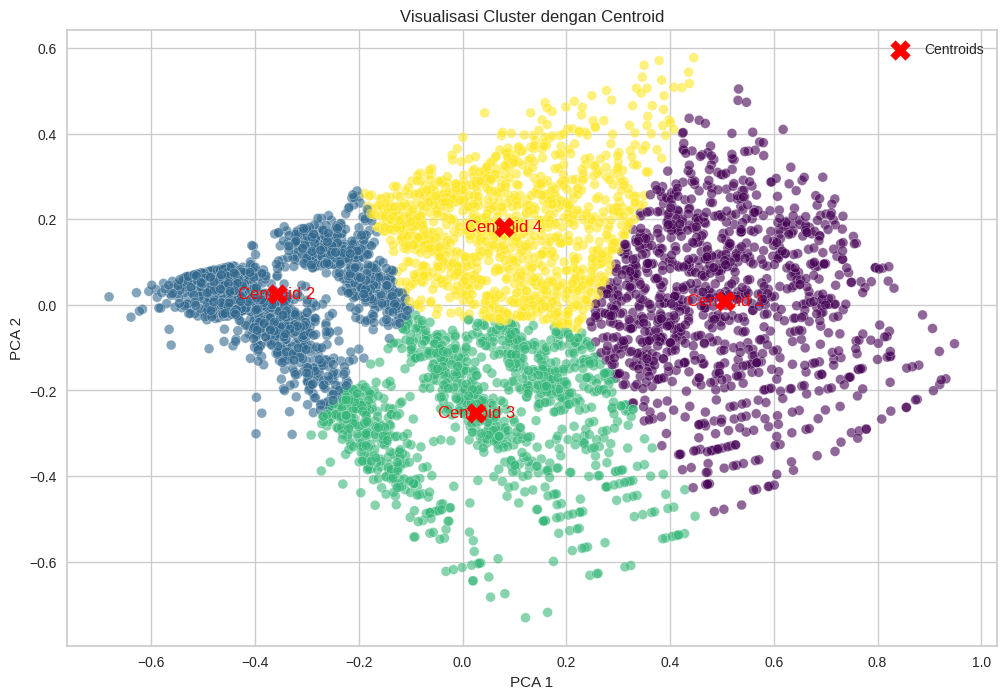


Nilai Centroids:
Centroid 1: PCA 1 = 0.51, PCA 2 = 0.01
Centroid 2: PCA 1 = -0.36, PCA 2 = 0.03
Centroid 3: PCA 1 = 0.03, PCA 2 = -0.25
Centroid 4: PCA 1 = 0.08, PCA 2 = 0.18


In [39]:
# Visualisasi Cluster dalam bentuk 2D menggunakan PCA
centroids = kmeans_pca.cluster_centers_

plt.figure(figsize=(12, 8))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()

plt.show()

print("\nNilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: PCA 1 = {centroid[0]:.2f}, PCA 2 = {centroid[1]:.2f}")

### Cluster Analysis

In [40]:
cluster_analysis = df_rfm_clean.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_scaled)) * 100)
).sort_values(by='Cluster')

cluster_analysis

,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster,,,,,
0,32.369837,8.500480,3942.603654,1041,20.057803
1,424.333697,1.312432,473.102117,1834,35.337187
2,246.196546,4.626645,1972.426715,1216,23.429672
3,37.687898,2.135578,1212.005782,1099,21.175337


In [41]:
# Memberikan label pada setiap cluster
def label_cluster(row):
    if row['Avg_Recency'] > cluster_analysis['Avg_Recency'].median():
       label_recency = 'High'
    else: label_recency = 'Low'

    if row['Avg_Frequency'] > cluster_analysis['Avg_Frequency'].median():
       label_frequency = 'High'
    else: label_frequency = 'Low'

    if row['Avg_Monetary'] > cluster_analysis['Avg_Monetary'].median():
       label_monetary = 'High'
    else: label_monetary = 'Low'

    if label_recency == 'Low' and label_frequency == 'High' and label_monetary == 'High':
        return 'Loyal Customers'
    elif label_frequency == 'High' and label_monetary == 'High':
        return 'High Risk Churns'
    elif label_recency == 'Low':
        return 'New Customers / Low Spenders'
    else: return 'Churns / One Time Spenders'

cluster_analysis['Label'] = cluster_analysis.apply(label_cluster, axis=1)
cluster_analysis

,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage,Label
Cluster,,,,,,
0,32.369837,8.500480,3942.603654,1041,20.057803,Loyal Customers
1,424.333697,1.312432,473.102117,1834,35.337187,Churns / One Time Spenders
2,246.196546,4.626645,1972.426715,1216,23.429672,High Risk Churns
3,37.687898,2.135578,1212.005782,1099,21.175337,New Customers / Low Spenders


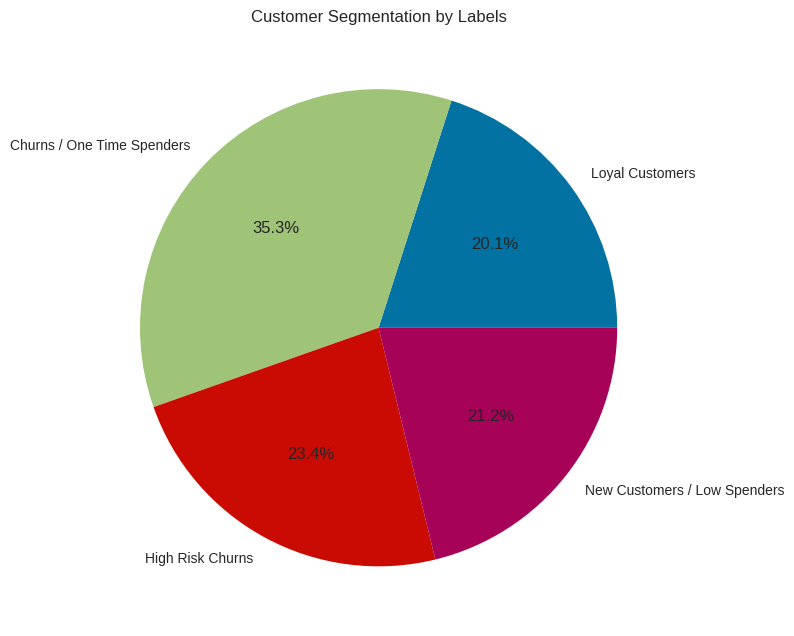

In [42]:
values = cluster_analysis['Percentage']
labels = cluster_analysis['Label']

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Segmentation by Labels')
plt.tight_layout()
plt.show()

# **Intepretasi Hasil Clustering**

In [43]:
df_rfm_clean.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max'])

Recency          Frequency             Monetary                   \
               mean min  max      mean min max         mean     min      max   
Cluster                                                                        
0         32.369837   1  219  8.500480   4  16  3942.603654  237.44  7844.18   
1        424.333697  52  739  1.312432   1   3   473.102117    2.95  4376.25   
2        246.196546  37  692  4.626645   2  15  1972.426715  101.15  7806.32   
3         37.687898   1  136  2.135578   1   4  1212.005782   37.85  7749.20   

        Cluster          
           mean min max  
Cluster                  
0           0.0   0   0  
1           1.0   1   1  
2           2.0   2   2  
3           3.0   3   3

## Karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (Customer dengan nilai Recency kecil, Frequency besar, dan Monetary besar)**
- **Rata-rata (mean) Recency:** 32.369837
- **Rata-rata (mean) Frequency:** 8.500480
- **Rata-rata (mean) Monetary:** 3942.603654
- **Analisis:** Cluster ini sebagian besar merupakan Loyal Customers. Memiliki kontribusi besar terhadap pendapatan bisnis dan harus dijadikan prioritas utama.

2. **Cluster 2: (Customer dengan nilai Recency besar, Frequency kecil, dan Monetary kecil)**
- **Rata-rata (mean) Recency:** 424.333697
- **Rata-rata (mean) Frequency:** 1.312432
- **Rata-rata (mean) Monetary:** 473.102117
- **Analisis:** Cluster ini kemungkinan besar diisi oleh Churns / One Time Spenders. Customer cenderung hanya mengeksplorasi atau tidak puas terhadap produk.

3. **Cluster 3: (Customer dengan nilai Recency besar, Frequency besar, dan Monetary besar)**
- **Rata-rata (mean) Recency:** 246.196546
- **Rata-rata (mean) Frequency:** 4.626645
- **Rata-rata (mean) Monetary:** 1972.426715
- **Analisis:** Cluster ini memiliki High Risk Churn. Sebelumnya menghasilkan kontribusi besar terhadap pendapatan bisnis, namun sekarang dibutuhkan perhatian khusus untuk mempertahankan retensinya.

4. **Cluster 4: (Customer dengan nilai Recency kecil, Frequency kecil, dan Monetary kecil)**
- **Rata-rata (mean) Recency:** 37.687898
- **Rata-rata (mean) Frequency:** 2.135578
- **Rata-rata (mean) Monetary:** 1212.005782
- **Analisis:** Cluster ini diisi oleh New Customers / Low Spenders. Memiliki peluang besar untuk dikembangkan menjadi Loyal Customer.


# **Post-processing**

In [44]:
cluster_to_label = cluster_analysis['Label'].to_dict()

df_rfm_clean['Label'] = df_rfm_clean['Cluster'].map(cluster_to_label)

df_rfm_clean.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Label
2,12348.0,75,5,3816.64,2,High Risk Churns
3,12349.0,19,4,6186.24,0,Loyal Customers
4,12350.0,310,1,668.80,1,Churns / One Time Spenders
5,12351.0,375,1,300.93,1,Churns / One Time Spenders
6,12352.0,36,10,5355.88,0,Loyal Customers


In [45]:
# Menggabungkan kembali Cluster beserta Labelnya ke dalam df Raw Data
df_final = df.copy()
df_final = df_final.merge(
    df_rfm_clean[['CustomerID', 'Cluster', 'Label']],
    on='CustomerID',
    how='left'
)

df_final

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,NaN,NaN
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,NaN,NaN
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,NaN,NaN
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,NaN,NaN
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1172112,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,0.0,Loyal Customers
1172113,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0.0,Loyal Customers
1172114,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0.0,Loyal Customers
1172115,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85,0.0,Loyal Customers


In [46]:
df_final.duplicated().sum()

np.int64(392692)

In [47]:
df_final.drop_duplicates(inplace=True)

df_final.duplicated().sum()

np.int64(0)

In [48]:
df_final.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
CustomerID,0
Country,0
TotalSales,0
Cluster,377499


In [49]:
df_final.dropna(inplace=True)

df_final.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
CustomerID,0
Country,0
TotalSales,0
Cluster,0


In [50]:
df_final

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.0,0.0,Loyal Customers
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.4,2.0,High Risk Churns
141,536382,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-01 09:45:00,0.85,16098.0,United Kingdom,10.2,0.0,Loyal Customers
142,536382,21912,VINTAGE SNAKES & LADDERS,8,2010-12-01 09:45:00,3.75,16098.0,United Kingdom,30.0,0.0,Loyal Customers
143,536382,21832,CHOCOLATE CALCULATOR,12,2010-12-01 09:45:00,1.65,16098.0,United Kingdom,19.8,0.0,Loyal Customers
...,...,...,...,...,...,...,...,...,...,...,...
779420,536364,21524,DOORMAT SPOTTY HOME SWEET HOME,2,2010-11-30 19:35:00,7.95,14441.0,United Kingdom,15.9,0.0,Loyal Customers
779421,536364,21098,CHRISTMAS TOILET ROLL,12,2010-11-30 19:35:00,1.25,14441.0,United Kingdom,15.0,0.0,Loyal Customers
779422,536364,21181,PLEASE ONE PERSON METAL SIGN,24,2010-11-30 19:35:00,2.10,14441.0,United Kingdom,50.4,0.0,Loyal Customers
779423,536364,22415,WHITE TISSUE REAM,10,2010-11-30 19:35:00,7.95,14441.0,United Kingdom,79.5,0.0,Loyal Customers


In [51]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401926 entries, 46 to 1172116
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      401926 non-null  object        
 1   StockCode    401926 non-null  object        
 2   Description  401926 non-null  object        
 3   Quantity     401926 non-null  int64         
 4   InvoiceDate  401926 non-null  datetime64[ns]
 5   Price        401926 non-null  float64       
 6   CustomerID   401926 non-null  float64       
 7   Country      401926 non-null  object        
 8   TotalSales   401926 non-null  float64       
 9   Cluster      401926 non-null  float64       
 10  Label        401926 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 36.8+ MB


In [52]:
df_final.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
count,401926,401926,401926,401926.000000,401926,401926.000000,401926.000000,401926,401926.000000,401926.000000,401926
unique,19229,4529,5096,NaN,NaN,NaN,NaN,39,NaN,NaN,4
top,543040,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,NaN,Loyal Customers
freq,244,2656,2653,NaN,NaN,NaN,NaN,375462,NaN,NaN,191248
mean,NaN,NaN,NaN,8.791603,2011-01-06 03:53:42.724879616,3.061323,15432.963745,NaN,14.606378,1.072260,NaN
min,NaN,NaN,NaN,1.000000,2009-12-01 07:45:00,0.001000,12348.000000,NaN,0.001000,0.000000,NaN
25%,NaN,NaN,NaN,2.000000,2010-07-08 09:13:00,1.250000,14105.000000,NaN,4.160000,0.000000,NaN
50%,NaN,NaN,NaN,4.000000,2010-11-28 13:21:00,1.950000,15507.000000,NaN,10.200000,1.000000,NaN
75%,NaN,NaN,NaN,12.000000,2011-08-16 15:39:00,3.750000,16794.000000,NaN,17.400000,2.000000,NaN
max,NaN,NaN,NaN,4300.000000,2011-12-09 12:50:00,3610.500000,18287.000000,NaN,3861.000000,3.000000,NaN


In [53]:
df_final[df_final['Cluster'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.0,0.0,Loyal Customers
141,536382,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-01 09:45:00,0.85,16098.0,United Kingdom,10.2,0.0,Loyal Customers
142,536382,21912,VINTAGE SNAKES & LADDERS,8,2010-12-01 09:45:00,3.75,16098.0,United Kingdom,30.0,0.0,Loyal Customers
143,536382,21832,CHOCOLATE CALCULATOR,12,2010-12-01 09:45:00,1.65,16098.0,United Kingdom,19.8,0.0,Loyal Customers
144,536382,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,10,2010-12-01 09:45:00,1.95,16098.0,United Kingdom,19.5,0.0,Loyal Customers
...,...,...,...,...,...,...,...,...,...,...,...
779420,536364,21524,DOORMAT SPOTTY HOME SWEET HOME,2,2010-11-30 19:35:00,7.95,14441.0,United Kingdom,15.9,0.0,Loyal Customers
779421,536364,21098,CHRISTMAS TOILET ROLL,12,2010-11-30 19:35:00,1.25,14441.0,United Kingdom,15.0,0.0,Loyal Customers
779422,536364,21181,PLEASE ONE PERSON METAL SIGN,24,2010-11-30 19:35:00,2.10,14441.0,United Kingdom,50.4,0.0,Loyal Customers
779423,536364,22415,WHITE TISSUE REAM,10,2010-11-30 19:35:00,7.95,14441.0,United Kingdom,79.5,0.0,Loyal Customers


In [54]:
df_final[df_final['Cluster'] == 1]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
153,536384,82484,WOOD BLACK BOARD ANT WHITE FINISH,3,2010-12-01 09:53:00,6.45,18074.0,United Kingdom,19.35,1.0,Churns / One Time Spenders
154,536384,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,48,2010-12-01 09:53:00,0.65,18074.0,United Kingdom,31.20,1.0,Churns / One Time Spenders
155,536384,22464,HANGING METAL HEART LANTERN,12,2010-12-01 09:53:00,1.65,18074.0,United Kingdom,19.80,1.0,Churns / One Time Spenders
156,536384,21324,HANGING MEDINA LANTERN SMALL,6,2010-12-01 09:53:00,2.95,18074.0,United Kingdom,17.70,1.0,Churns / One Time Spenders
157,536384,22457,NATURAL SLATE HEART CHALKBOARD,12,2010-12-01 09:53:00,2.95,18074.0,United Kingdom,35.40,1.0,Churns / One Time Spenders
...,...,...,...,...,...,...,...,...,...,...,...
779324,536354,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2,2010-11-30 17:43:00,2.95,17820.0,United Kingdom,5.90,1.0,Churns / One Time Spenders
779325,536354,21201,TROPICAL HONEYCOMB PAPER GARLAND,4,2010-11-30 17:43:00,2.55,17820.0,United Kingdom,10.20,1.0,Churns / One Time Spenders
779326,536354,22748,POPPY'S PLAYHOUSE KITCHEN,1,2010-11-30 17:43:00,2.10,17820.0,United Kingdom,2.10,1.0,Churns / One Time Spenders
779327,536354,22839,3 TIER CAKE TIN GREEN AND CREAM,1,2010-11-30 17:43:00,14.95,17820.0,United Kingdom,14.95,1.0,Churns / One Time Spenders


In [55]:
df_final[df_final['Cluster'] == 2]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40,2.0,High Risk Churns
181,536388,21754,HOME BUILDING BLOCK WORD,3,2010-12-01 09:59:00,5.95,16250.0,United Kingdom,17.85,2.0,High Risk Churns
182,536388,21755,LOVE BUILDING BLOCK WORD,3,2010-12-01 09:59:00,5.95,16250.0,United Kingdom,17.85,2.0,High Risk Churns
183,536388,21523,DOORMAT FANCY FONT HOME SWEET HOME,2,2010-12-01 09:59:00,7.95,16250.0,United Kingdom,15.90,2.0,High Risk Churns
184,536388,21363,HOME SMALL WOOD LETTERS,3,2010-12-01 09:59:00,4.95,16250.0,United Kingdom,14.85,2.0,High Risk Churns
...,...,...,...,...,...,...,...,...,...,...,...
779378,536360,22423,REGENCY CAKESTAND 3 TIER,3,2010-11-30 18:21:00,12.75,13693.0,United Kingdom,38.25,2.0,High Risk Churns
779379,536360,22890,NOVELTY BISCUITS CAKE STAND 3 TIER,2,2010-11-30 18:21:00,9.95,13693.0,United Kingdom,19.90,2.0,High Risk Churns
779380,536360,22766,PHOTO FRAME CORNICE,8,2010-11-30 18:21:00,2.95,13693.0,United Kingdom,23.60,2.0,High Risk Churns
779381,536360,22325,MOBILE VINTAGE HEARTS,3,2010-11-30 18:21:00,4.95,13693.0,United Kingdom,14.85,2.0,High Risk Churns


In [56]:
df_final[df_final['Cluster'] == 3]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Cluster,Label
655,536416,21494,ROTATING LEAVES T-LIGHT HOLDER,12,2010-12-01 11:58:00,1.25,13255.0,United Kingdom,15.00,3.0,New Customers / Low Spenders
656,536416,21915,RED HARMONICA IN BOX,72,2010-12-01 11:58:00,1.25,13255.0,United Kingdom,90.00,3.0,New Customers / Low Spenders
657,536416,22938,CUPCAKE LACE PAPER SET 6,12,2010-12-01 11:58:00,1.95,13255.0,United Kingdom,23.40,3.0,New Customers / Low Spenders
658,536416,22768,FAMILY PHOTO FRAME CORNICE,4,2010-12-01 11:58:00,9.95,13255.0,United Kingdom,39.80,3.0,New Customers / Low Spenders
659,536416,22767,TRIPLE PHOTO FRAME CORNICE,4,2010-12-01 11:58:00,9.95,13255.0,United Kingdom,39.80,3.0,New Customers / Low Spenders
...,...,...,...,...,...,...,...,...,...,...,...
777609,536066,84819,DANISH ROSE ROUND SEWING BOX,3,2010-11-30 10:47:00,4.25,12586.0,Italy,12.75,3.0,New Customers / Low Spenders
777610,536066,22765,NEWSPAPER STAND,1,2010-11-30 10:47:00,14.95,12586.0,Italy,14.95,3.0,New Customers / Low Spenders
777611,536066,21288,STRIPEY CHOCOLATE NESTING BOXES,6,2010-11-30 10:47:00,2.95,12586.0,Italy,17.70,3.0,New Customers / Low Spenders
777612,536066,84840,SWEETHEART CARRY-ALL BASKET,2,2010-11-30 10:47:00,8.50,12586.0,Italy,17.00,3.0,New Customers / Low Spenders


In [57]:
df_final.to_csv('online_retail_uci_clustering.csv', index=False)

End of Code.